# Визуализация единой multiclass photoswitch-модели

Notebook читает свежий balanced top-1000 из
`generated_multiclass_photoswitch.csv`, полученный одним conditional
SELFIES-GRU с family-токенами `<AZO>` и `<STILBENE>`.

Оба класса имеют явные E/Z-пары и общий UV proxy. Azo дополнительно имеет
обучаемые half-life и E/Z spectral-separation proxies. Для stilbene-like
half-life, PSS, quantum yield, ΔH и stored energy отсутствуют и не подменяются.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

RDLogger.DisableLog("rdApp.*")
ROOT = Path.cwd().resolve()
CSV_PATH = ROOT / "generated_multiclass_photoswitch.csv"
METRICS_PATH = ROOT / "outputs" / "uv_most_multiclass" / "generation_metrics.csv"
df = pd.read_csv(CSV_PATH)
required = {
    "selection_rank", "candidate_id", "rank_within_family", "family",
    "canonical_smiles", "state_A_smiles", "state_B_smiles",
    "pair_valid", "eval_uv_lambda_nm", "eval_uv_uncertainty_nm", "sa_score",
    "reward", "selection_score", "target_A_pass", "target_B_pass",
    "joint_success", "PSS_pred", "quantum_yield_pred", "deltaH_kJ_mol",
    "stored_energy_MJ_kg", "final_status",
}
missing = required.difference(df.columns)
if missing:
    raise KeyError(f"generated_multiclass_photoswitch.csv is missing: {sorted(missing)}")
if len(df) != 1000 or df["canonical_smiles"].nunique() != 1000:
    raise ValueError("Expected exactly 1000 globally unique fresh candidates")
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print("Families:", df["family"].value_counts().to_dict())
print("Unique structures:", df.groupby("family")["canonical_smiles"].nunique().to_dict())
print("Selection ranks:", (int(df["selection_rank"].min()), int(df["selection_rank"].max())))

Loaded 1,000 rows from /home/sigmatau17/TEST/generated_multiclass_photoswitch.csv
Families: {'azo': 500, 'stilbene': 500}
Unique structures: {'azo': 500, 'stilbene': 500}
Selection ranks: (1, 1000)


## Состав свежего top-1000 и ранжирование

,family,rows,unique,proxy_pass,median_uv_nm,median_uv_uncertainty_nm,median_sa,median_selection_score
0,azo,500,500,500,391.511785,59.778436,2.981779,0.228135
1,stilbene,500,500,500,359.214803,59.778436,2.443837,0.349333


final_status,PASS_AZO_PROXY,PASS_STILBENE_STRUCTURAL_PROXY
family,,
azo,500,0
stilbene,0,500


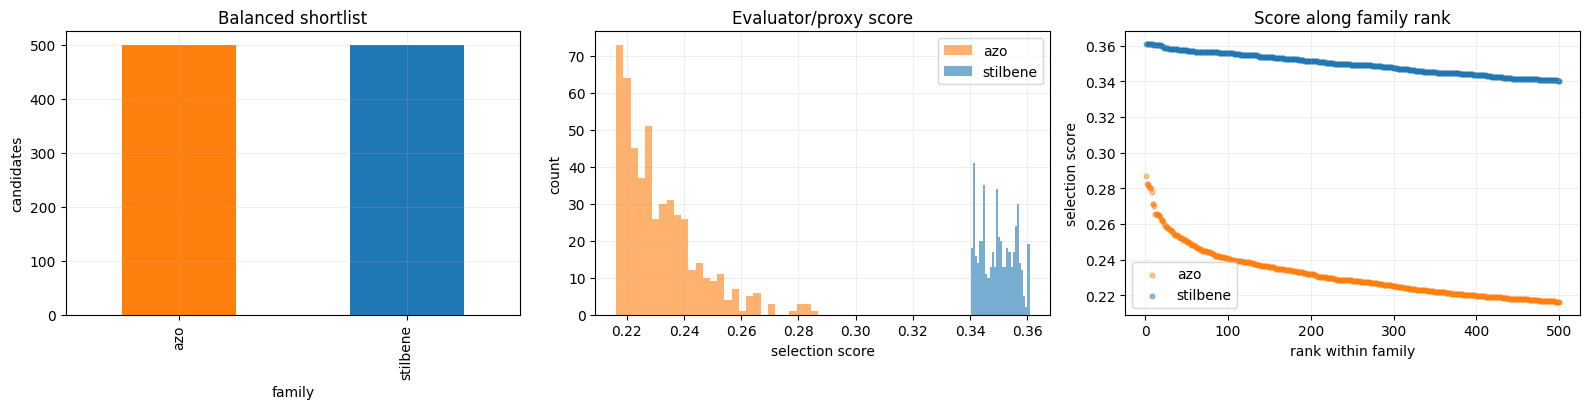

In [2]:
summary = (
    df.groupby("family", as_index=False)
      .agg(
          rows=("canonical_smiles", "size"),
          unique=("canonical_smiles", "nunique"),
          proxy_pass=("final_status", lambda x: int(x.str.startswith("PASS").sum())),
          median_uv_nm=("eval_uv_lambda_nm", "median"),
          median_uv_uncertainty_nm=("eval_uv_uncertainty_nm", "median"),
          median_sa=("sa_score", "median"),
          median_selection_score=("selection_score", "median"),
      )
)
display(summary)
display(pd.crosstab(df["family"], df["final_status"]))

colors = {"azo": "tab:orange", "stilbene": "tab:blue"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
df["family"].value_counts().reindex(["azo", "stilbene"]).plot.bar(
    ax=axes[0], color=[colors["azo"], colors["stilbene"]]
)
axes[0].set(title="Balanced shortlist", xlabel="family", ylabel="candidates")
for family, part in df.groupby("family"):
    axes[1].hist(part["selection_score"], bins=28, alpha=0.6, color=colors[family], label=family)
    axes[2].scatter(
        part["rank_within_family"], part["selection_score"],
        s=11, alpha=0.45, color=colors[family], label=family,
    )
axes[1].set(title="Evaluator/proxy score", xlabel="selection score", ylabel="count")
axes[2].set(title="Score along family rank", xlabel="rank within family", ylabel="selection score")
for axis in axes[1:]:
    axis.legend()
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Общий UV proxy и synthetic accessibility

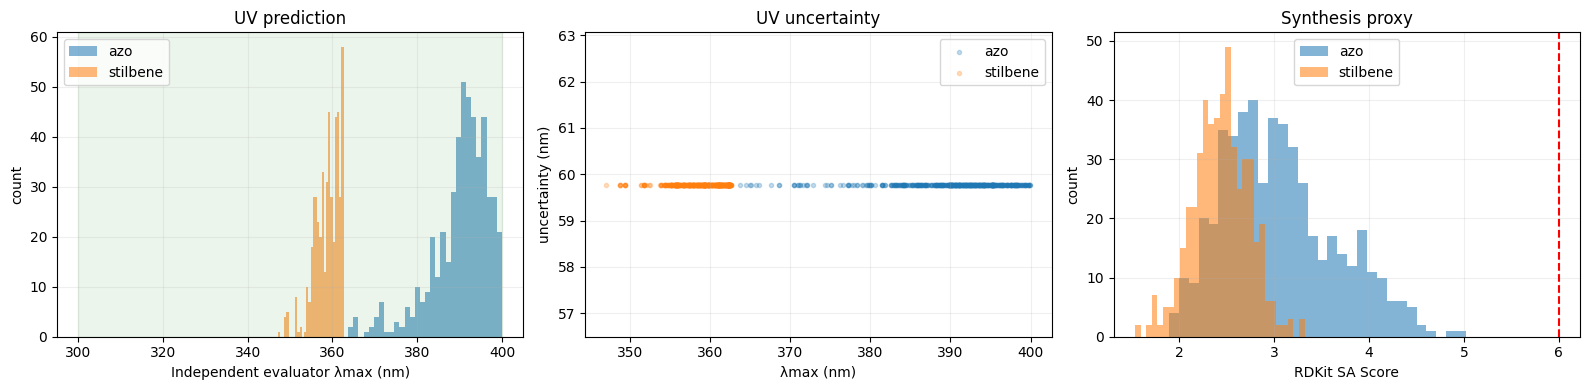

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for family, part in df.groupby("family"):
    axes[0].hist(part["eval_uv_lambda_nm"], bins=30, alpha=0.55, label=family)
    axes[1].scatter(part["eval_uv_lambda_nm"], part["eval_uv_uncertainty_nm"], s=9, alpha=0.25, label=family)
    axes[2].hist(part["sa_score"], bins=30, alpha=0.55, label=family)
axes[0].axvspan(300, 400, color="green", alpha=0.08)
axes[0].set(xlabel="Independent evaluator λmax (nm)", ylabel="count", title="UV prediction")
axes[1].set(xlabel="λmax (nm)", ylabel="uncertainty (nm)", title="UV uncertainty")
axes[2].axvline(6.0, color="red", ls="--")
axes[2].set(xlabel="RDKit SA Score", ylabel="count", title="Synthesis proxy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Azo-specific spectral separation и half-life

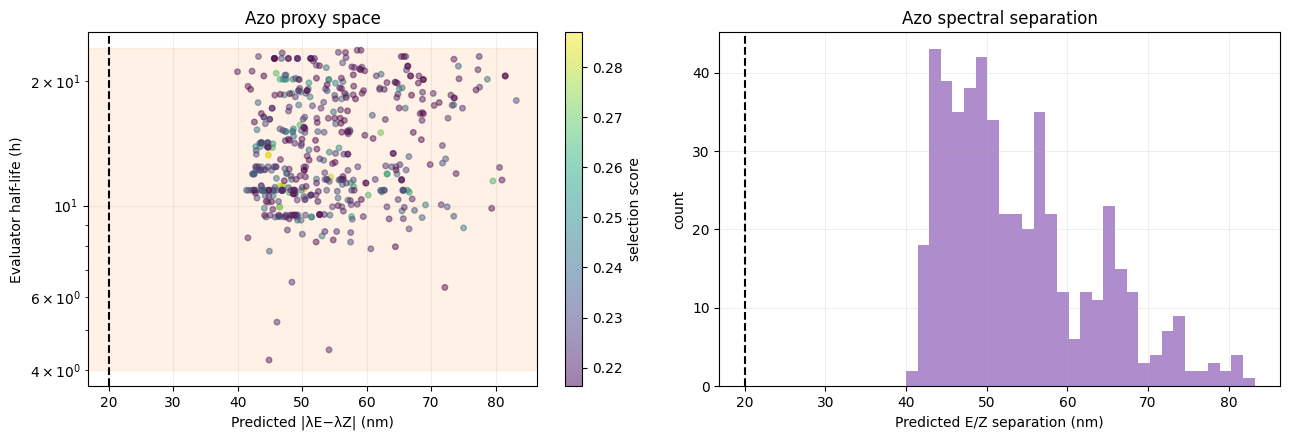

In [4]:
azo = df[df["family"].eq("azo")].dropna(subset=["pred_delta_lambda_nm", "eval_half_life_h"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
scatter = axes[0].scatter(
    azo["pred_delta_lambda_nm"], azo["eval_half_life_h"],
    c=azo["selection_score"], cmap="viridis", s=16, alpha=0.5,
)
axes[0].axvline(20, color="black", ls="--")
axes[0].axhspan(4, 24, color="tab:orange", alpha=0.1)
axes[0].set_yscale("log")
axes[0].set(xlabel="Predicted |λE−λZ| (nm)", ylabel="Evaluator half-life (h)", title="Azo proxy space")
fig.colorbar(scatter, ax=axes[0], label="selection score")
axes[1].hist(azo["pred_delta_lambda_nm"], bins=30, color="tab:purple", alpha=0.75)
axes[1].axvline(20, color="black", ls="--")
axes[1].set(xlabel="Predicted E/Z separation (nm)", ylabel="count", title="Azo spectral separation")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Лучшие E/Z-пары каждого класса

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
0,MC-AZO-0001,1,Cc1ccccc1N=Nc1ccccc1C=Nc1ccccc1,Cc1ccccc1/N=N/c1ccccc1C=Nc1ccccc1,Cc1ccccc1/N=N\c1ccccc1C=Nc1ccccc1,368.608243,2.388907,0.286920,PASS_AZO_PROXY
1,MC-AZO-0002,2,CN=NC=NC(C)=C/N=N/C=Cc1ccccc1C,C/N=N/C=NC(C)=C/N=N/C=Cc1ccccc1C,C/N=N\C=NC(C)=C/N=N/C=Cc1ccccc1C,363.702412,4.127752,0.282261,PASS_AZO_PROXY
2,MC-AZO-0003,3,Cc1ccccc1/N=C/c1ccccc1N=Nc1ccccc1,Cc1ccccc1/N=C/c1ccccc1/N=N/c1ccccc1,Cc1ccccc1/N=C/c1ccccc1/N=N\c1ccccc1,370.464111,2.395442,0.282161,PASS_AZO_PROXY
3,MC-AZO-0004,4,Cc1ccccc1N=Nc1ccccc1N=Nc1ccccc1N=Nc1ccccc1C=Nc...,Cc1ccccc1/N=N/c1ccccc1N=Nc1ccccc1N=Nc1ccccc1C=...,Cc1ccccc1/N=N\c1ccccc1N=Nc1ccccc1N=Nc1ccccc1C=...,371.235171,2.894514,0.281883,PASS_AZO_PROXY
4,MC-AZO-0005,5,CC=NC=NC(C)=CN=NC=Cc1ccccc1C,CC=NC=NC(C)=C/N=N/C=Cc1ccccc1C,CC=NC=NC(C)=C/N=N\C=Cc1ccccc1C,365.680913,4.054293,0.280461,PASS_AZO_PROXY
5,MC-AZO-0006,6,CC=NC/N=N/c1ccccc1C,CC=NC/N=N/c1ccccc1C,CC=NC/N=N\c1ccccc1C,372.072847,3.267751,0.280278,PASS_AZO_PROXY
6,MC-AZO-0007,7,CN=NC(C)=CNN=NC=Cc1ccccc1C=Cc1ccccc1C,C/N=N/C(C)=CNN=NC=Cc1ccccc1C=Cc1ccccc1C,C/N=N\C(C)=CNN=NC=Cc1ccccc1C=Cc1ccccc1C,370.499955,3.535747,0.280061,PASS_AZO_PROXY
7,MC-AZO-0008,8,CC=NC=NN=NC(C)=C/N=N/C=Cc1ccccc1C,CC=NC=N/N=N/C(C)=C/N=N/C=Cc1ccccc1C,CC=NC=N\N=N/C(C)=C\N=N\C=Cc1ccccc1C,365.030578,4.316651,0.277833,PASS_AZO_PROXY
8,MC-AZO-0009,9,C#C/N=N/c1ccccc1C,C#C/N=N/c1ccccc1C,C#C/N=N\c1ccccc1C,377.259454,3.113893,0.271373,PASS_AZO_PROXY


azo: state A


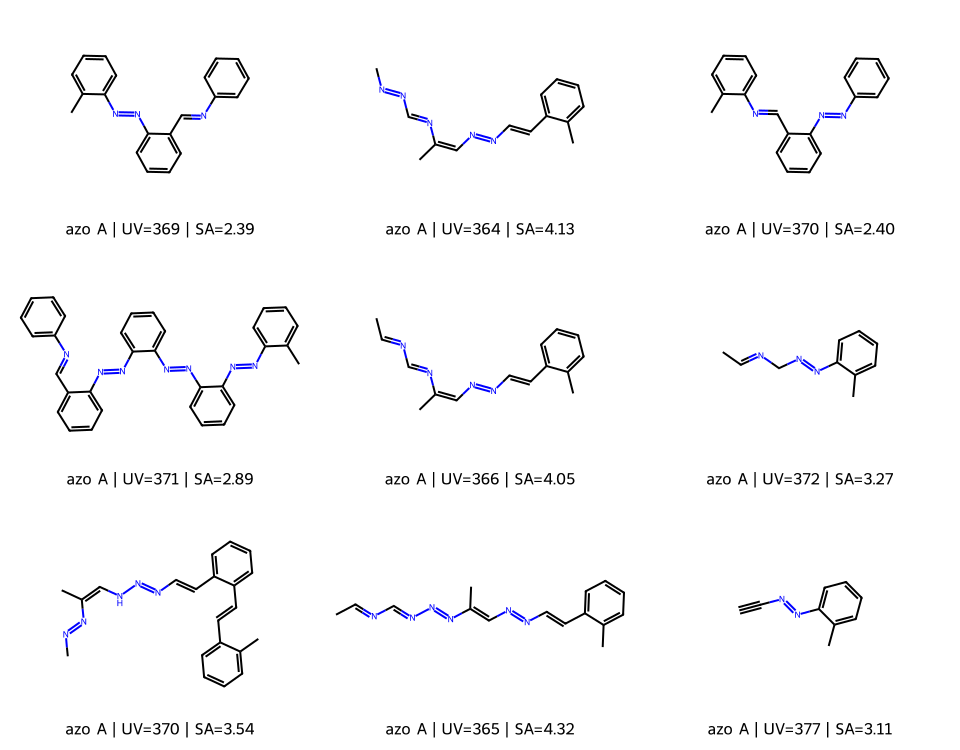

azo: corresponding state B


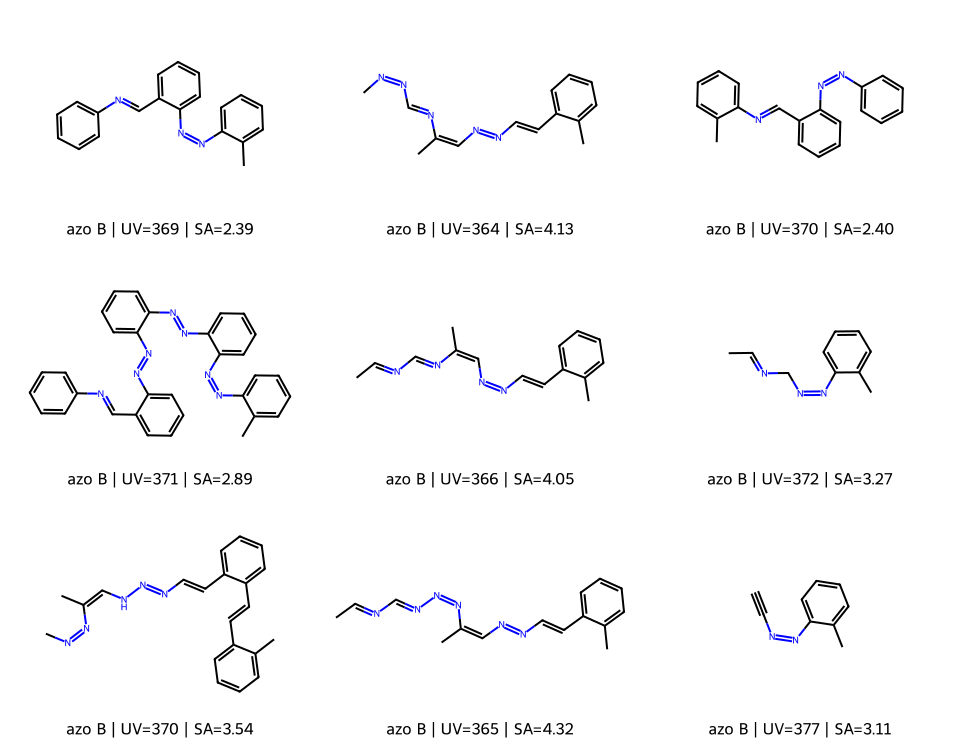

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
500,MC-STILBENE-0501,1,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C/c1ccccc1-c1ccccc1C,Cc1ccccc1/C=C\c1ccccc1-c1ccccc1C,349.332798,1.850764,0.360740,PASS_STILBENE_STRUCTURAL_PROXY
501,MC-STILBENE-0502,2,Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1ccccc1-c1ccc...,Cc1ccccc1/C=C/c1ccccc1-c1ccccc1C=Cc1ccccc1-c1c...,Cc1ccccc1/C=C\c1ccccc1-c1ccccc1C=Cc1ccccc1-c1c...,349.332798,2.035335,0.360740,PASS_STILBENE_STRUCTURAL_PROXY
502,MC-STILBENE-0503,3,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1-c1ccccc1C,Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1-c1ccccc1C,349.332798,2.035512,0.360740,PASS_STILBENE_STRUCTURAL_PROXY
503,MC-STILBENE-0504,4,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1c...,Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c...,Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c...,349.332798,2.199821,0.360740,PASS_STILBENE_STRUCTURAL_PROXY
504,MC-STILBENE-0505,5,Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc...,Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=...,Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=...,349.332798,2.381178,0.360740,PASS_STILBENE_STRUCTURAL_PROXY
505,MC-STILBENE-0506,6,CC=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,CC=Cc1ccccc1/C=C/c1ccccc1-c1ccccc1C,CC=Cc1ccccc1/C=C\c1ccccc1-c1ccccc1C,348.745849,2.174331,0.360586,PASS_STILBENE_STRUCTURAL_PROXY
506,MC-STILBENE-0507,7,CC=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C=Cc1ccccc1-c1...,CC=Cc1ccccc1/C=C/c1ccccc1-c1ccccc1C=Cc1ccccc1-...,CC=Cc1ccccc1/C=C\c1ccccc1-c1ccccc1C=Cc1ccccc1-...,348.745849,2.311753,0.360586,PASS_STILBENE_STRUCTURAL_PROXY
507,MC-STILBENE-0508,8,CC=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-c1ccccc1C,CC=Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1-c1ccccc1C,CC=Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1-c1ccccc1C,348.745849,2.300155,0.360586,PASS_STILBENE_STRUCTURAL_PROXY
508,MC-STILBENE-0509,9,CC=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1-...,CC=Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc...,CC=Cc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc...,348.745849,2.434535,0.360586,PASS_STILBENE_STRUCTURAL_PROXY


stilbene: state A


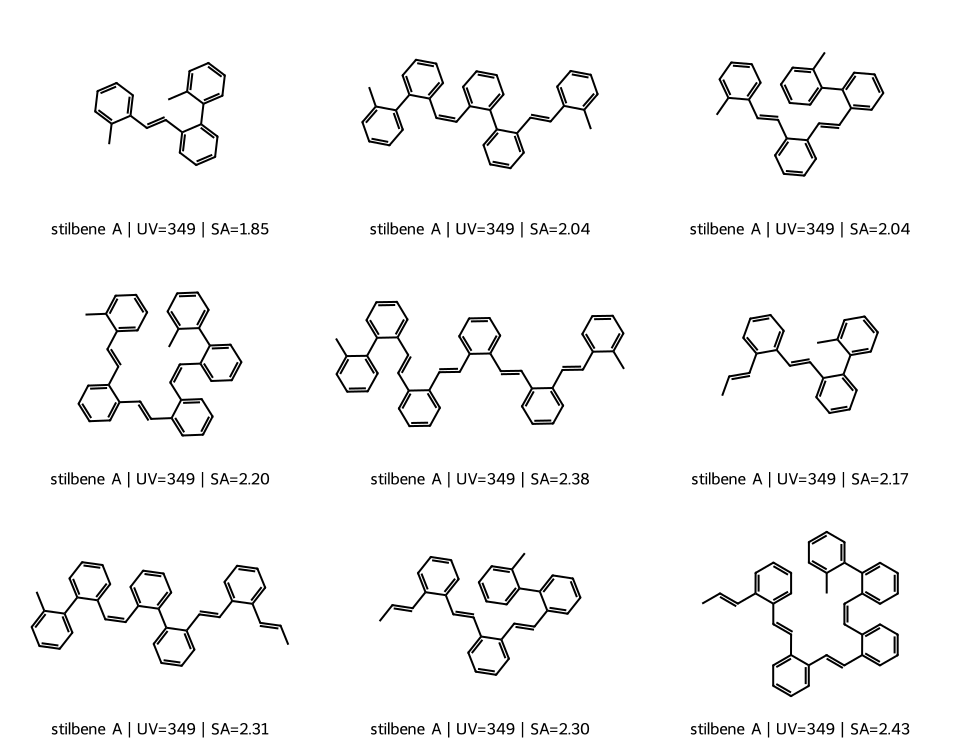

stilbene: corresponding state B


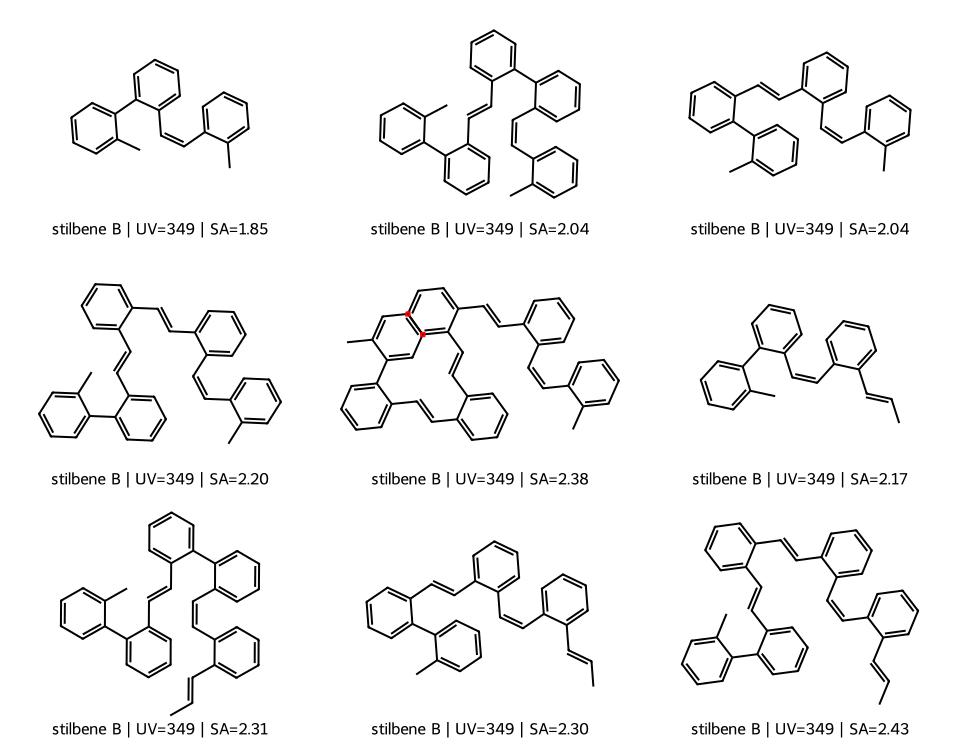

In [5]:
def show_family_pairs(family, count=9):
    top = (
        df[df["family"].eq(family)]
        .sort_values("rank_within_family")
        .drop_duplicates("canonical_smiles")
        .head(count)
    )
    display(top[[
        "candidate_id", "rank_within_family", "canonical_smiles",
        "state_A_smiles", "state_B_smiles", "eval_uv_lambda_nm", "sa_score",
        "selection_score", "final_status",
    ]])
    state_a = [Chem.MolFromSmiles(s) for s in top["state_A_smiles"]]
    state_b = [Chem.MolFromSmiles(s) for s in top["state_B_smiles"]]
    legends_a = [f"{family} A | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    legends_b = [f"{family} B | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    print(f"{family}: state A")
    display(Draw.MolsToGridImage(state_a, legends=legends_a, molsPerRow=3, subImgSize=(320, 250), useSVG=True))
    print(f"{family}: corresponding state B")
    display(Draw.MolsToGridImage(state_b, legends=legends_b, molsPerRow=3, subImgSize=(320, 250), useSVG=True))

show_family_pairs("azo")
show_family_pairs("stilbene")

### Научная граница результата

Оба класса генерируются одним checkpoint. Для azo доступны M01-derived half-life
и E/Z spectral proxies. Для stilbene-like подтверждены лишь diaryl/heteroaryl
alkene E/Z pair и общий UVVisML proxy. PSS, quantum yield, ΔH и stored energy
намеренно остаются пустыми для обоих классов до физической валидации.

## Метрики генерации

Отдельный финальный вывод показывает метрики как для всех 36 000 proposals,
так и для отобранного top-1000. Единичные метрики top-1000 являются следствием
целевого отбора; качество самого generator следует оценивать по scope
`all_proposals`.

,metric,definition
0,Validity,Nvalid / Ngenerated
1,Uniqueness,Nunique_valid / Nvalid
2,Novelty,Nunique_valid_not_in_training / Nunique_valid
3,JSR,N(target_A_pass AND target_B_pass) / Ngenerated
4,Diversity,1 - mean pairwise Morgan/Tanimoto similarity o...


,scope,family,n_generated,n_valid,n_unique,n_not_in_training,n_joint_success,validity,uniqueness,novelty,joint_success_rate,diversity
0,all_proposals,all,36000,35998,26568,26564,19942,0.999944,0.738041,0.999849,0.553944,0.785712
1,all_proposals,azo,6000,5999,5507,5505,1148,0.999833,0.917986,0.999637,0.191333,0.808092
2,all_proposals,stilbene,30000,29999,21120,21118,18794,0.999967,0.704023,0.999905,0.626467,0.758991
3,top_1000,all,1000,1000,1000,1000,1000,1.000000,1.000000,1.000000,1.000000,0.729000
4,top_1000,azo,500,500,500,500,500,1.000000,1.000000,1.000000,1.000000,0.735075
5,top_1000,stilbene,500,500,500,500,500,1.000000,1.000000,1.000000,1.000000,0.604556


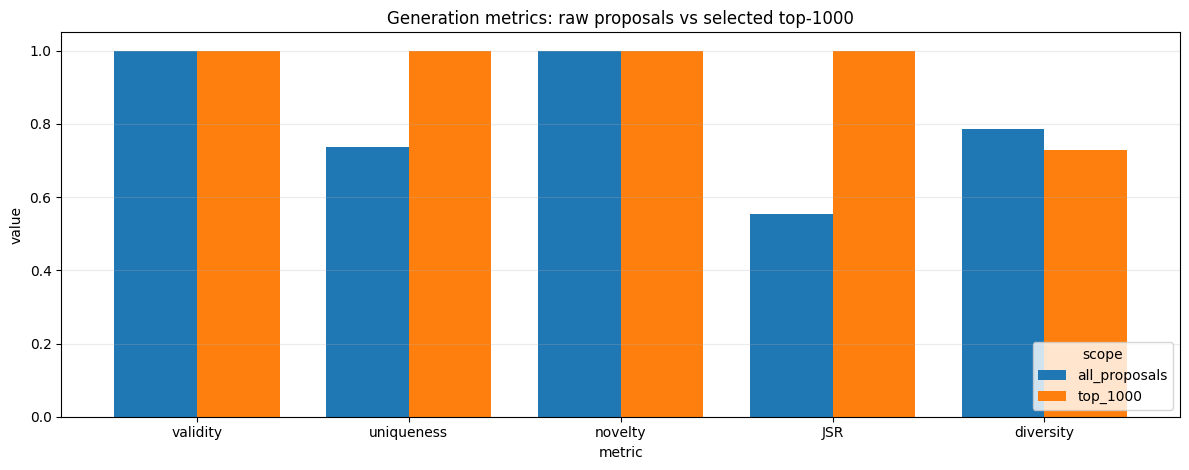

In [6]:
metrics = pd.read_csv(METRICS_PATH)
required_metrics = {
    "scope", "family", "n_generated", "n_valid", "n_unique",
    "n_not_in_training", "n_joint_success", "validity", "uniqueness",
    "novelty", "joint_success_rate", "diversity",
}
missing_metrics = required_metrics.difference(metrics.columns)
if missing_metrics:
    raise KeyError(f"generation_metrics.csv is missing: {sorted(missing_metrics)}")

scope_order = ["all_proposals", "top_1000"]
family_order = ["all", "azo", "stilbene"]
metrics["scope"] = pd.Categorical(metrics["scope"], scope_order, ordered=True)
metrics["family"] = pd.Categorical(metrics["family"], family_order, ordered=True)
metrics = metrics.sort_values(["scope", "family"]).reset_index(drop=True)

formulas = pd.DataFrame({
    "metric": ["Validity", "Uniqueness", "Novelty", "JSR", "Diversity"],
    "definition": [
        "Nvalid / Ngenerated",
        "Nunique_valid / Nvalid",
        "Nunique_valid_not_in_training / Nunique_valid",
        "N(target_A_pass AND target_B_pass) / Ngenerated",
        "1 - mean pairwise Morgan/Tanimoto similarity over unique valid structures",
    ],
})
display(formulas)

metrics_display = metrics.copy()
rate_columns = ["validity", "uniqueness", "novelty", "joint_success_rate", "diversity"]
metrics_display[rate_columns] = metrics_display[rate_columns].round(6)
display(metrics_display)

overall = (
    metrics[metrics["family"].eq("all")]
    .set_index("scope")[rate_columns]
    .rename(columns={"joint_success_rate": "JSR"})
)
axes = overall.T.plot.bar(figsize=(12, 4.8), ylim=(0, 1.05), width=0.78)
axes.set(title="Generation metrics: raw proposals vs selected top-1000", xlabel="metric", ylabel="value")
axes.grid(axis="y", alpha=0.25)
axes.legend(title="scope", loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()